In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_all_user_json_curves_single(json_dir, max_event=650, model = None):
    """
    Plot average EER (and AUC optionally) curves for all JSON files inside a folder.
    Each JSON file represents a model experiment, and each contributes one curve.

    Parameters
    ----------
    json_dir : str or Path
        Path to the folder containing JSON result files (e.g. 'Training/Results/train_all_user_1DCNN')
    max_event : int
        Maximum number of events to display on the x-axis
    """
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            # Set multiplier based on file name
            if "traj" in json_file.stem.lower():
                multiplier = 25.22
            elif "PeakClick" in json_file.stem:
                multiplier = 19.3
            else:
                multiplier = 1.0

            # Skip empty files
            if json_file.stat().st_size == 0:
                print(f"[SKIP] Empty file: {json_file.name}")
                continue

            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)

            # Aggregate per-user results
            user_eers = []
            ns = None
            for user, records in data.items():
                n_vals = []
                eers = []
                for k, v in records.items():
                    n_vals.append(v["n"])
                    eers.append(v["EER"])
                user_eers.append(eers)
                ns = n_vals  # same for all users

            # Compute average EER across users
            user_eers = np.array(user_eers)
            avg_eer = np.mean(user_eers, axis=0)

            # Compute event x-axis
            events = np.array(ns) * multiplier
            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8, label=json_file.stem)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Max = {max_event})", fontsize=13, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# color fixed
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

def plot_chunk_json_curves(json_dir, max_event=650, model=None):
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            name = json_file.stem

            if "PeakClick" in name:
                multiplier = 19.3
                chunk_key = "PeakClick"
            else:
                match = re.search(r"ChunkSize(\d+)", name)
                chunk_key = match.group(1) if match else None
                multiplier = float(chunk_key) if chunk_key else 1.0

            color = chunk_color_map.get(chunk_key, "black")

            with open(json_file, "r") as f:
                data = json.load(f)

            n = np.array(data["n"])
            avg_eer = np.array(data["avg_eer"])
            events = n * multiplier

            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8,
                     color=color, label=name)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Chunk Size Experiments)", fontsize=13, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)

    # ---- chunk size ranking ----
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(zip(handles, labels), key=lambda x: extract_size(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(sorted_handles, sorted_labels, fontsize=10)

    plt.tight_layout()
    plt.show()


In [3]:
import re
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}


def parse_chunk_size_from_filename(fname):
    """
    ChunkSize120BinaryViT.json -> "120"
    """
    match = re.search(r"ChunkSize(\d+)", fname)
    if match is None:
        raise ValueError(f"Cannot parse chunk size from {fname}")
    return match.group(1)   

import json
import numpy as np

def load_avg_eer_from_json(json_path, chunk_size, max_event=None):
    """
    Compute average EER vs #events (NOT images).
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    eer_by_event = {}

    for user, records in data.items():
        for n_str, metrics in records.items():
            n_img = int(n_str)
            n_event = n_img * chunk_size   

            if max_event is not None and n_event > max_event:
                continue

            eer = metrics.get("EER", None)
            if eer is None:
                continue

            eer_by_event.setdefault(n_event, []).append(eer)

    events = sorted(eer_by_event.keys())
    avg_eer = [np.mean(eer_by_event[e]) for e in events]

    return np.array(events), np.array(avg_eer)

import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def plot_avg_eer_curves(base_dir, max_event=650, model=None):
    plt.figure(figsize=(8, 5))

    curves = []

    for fname in os.listdir(base_dir):
        if not fname.endswith(".json"):
            continue

        chunk = parse_chunk_size_from_filename(fname)  # "10", "15", ...
        if chunk not in chunk_color_map:
            continue

        json_path = os.path.join(base_dir, fname)

        events, avg_eer = load_avg_eer_from_json(
            json_path,
            chunk_size=int(chunk),
            max_event=max_event
        )

        curves.append((int(chunk), events, avg_eer))

    
    curves.sort(key=lambda x: x[0])


    for chunk, events, avg_eer in curves:
        plt.plot(
            events,
            avg_eer,
            marker="o",
            linewidth=2,
            color=chunk_color_map[str(chunk)],
            label=f"ChunkSize{chunk}MultiViT"
        )

    plt.xlabel("# Events")
    plt.ylabel("Average EER")
    plt.title(
        f"Average EER vs #Events\n{model}"
        if model else "Average EER vs #Events"
    )

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================
# Fixed color map
# =========================
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

# =========================
# Plot XY + CDF together
# =========================
def plot_chunk_xy_cdf_curves(
    xy_dir,
    cdf_dir,
    max_event=650,
    model=None,
    title=None
):
    xy_dir = Path(xy_dir)
    cdf_dir = Path(cdf_dir)

    plt.figure(figsize=(9, 5))

    # -------------------------
    # Internal plotting helper
    # -------------------------
    def plot_from_dir(json_dir, linestyle, suffix):
        for json_file in json_dir.glob("*.json"):
            try:
                name = json_file.stem

                # ---- chunk key & multiplier ----
                if "PeakClick" in name:
                    chunk_key = "PeakClick"
                    multiplier = 19.3
                else:
                    match = re.search(r"ChunkSize(\d+)", name)
                    chunk_key = match.group(1) if match else None
                    multiplier = float(chunk_key) if chunk_key else 1.0

                color = chunk_color_map.get(chunk_key, "black")

                # ---- load JSON ----
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])
                events = n * multiplier

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{name} ({suffix})"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle=linestyle,
                    linewidth=2,
                    marker="o",
                    markersize=4,
                    color=color,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file.name}: {e}")

    # -------------------------
    # Plot XY (solid) + CDF (dashed)
    # -------------------------
    plot_from_dir(xy_dir, linestyle="-",  suffix="XY")
    plot_from_dir(cdf_dir, linestyle="--", suffix="CDF")

    # -------------------------
    # Axes & title
    # -------------------------
    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)

    if title is not None:
        plt.title(title, fontsize=13, weight="bold")
    else:
        plt.title(
            f"{model} (Chunk Size: XY vs CDF)",
            fontsize=13,
            weight="bold"
        )

    plt.grid(True, linestyle="--", alpha=0.6)

    # -------------------------
    # Legend sorting by chunk size
    # -------------------------
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(
        zip(handles, labels),
        key=lambda x: extract_size(x[1])
    )

    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(
        sorted_handles,
        sorted_labels,
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import colorsys


# ============================================================
# Generate vivid distinct colors
# ============================================================
def generate_vivid_colors(n):
    """
    Generate n visually distinct vivid colors using HSV space.
    """
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.9
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors


# ============================================================
# Plot multiple result folders (vivid color version)
# ============================================================
def plot_multiple_result_dirs(
    dir_list,
    chunk_sizes,
    max_event=650,
    title=None
):
    dir_list = [Path(d) for d in dir_list]

    # ---- chunk size handling ----
    if isinstance(chunk_sizes, int):
        chunk_sizes = [chunk_sizes] * len(dir_list)

    if len(chunk_sizes) != len(dir_list):
        raise ValueError("chunk_sizes must match number of directories")

    # ---- colorful palette ----
    colors = generate_vivid_colors(len(dir_list))

    plt.figure(figsize=(10, 6))

    # ========================================================
    # Loop over folders
    # ========================================================
    for dir_idx, result_dir in enumerate(dir_list):

        color = colors[dir_idx]
        chunk_size = chunk_sizes[dir_idx]
        dir_name = result_dir.name

        for json_file in result_dir.glob("*.json"):

            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])

                events = n * chunk_size

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{dir_name} - {json_file.stem}"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle="-",
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file}: {e}")

    # ========================================================
    # Styling
    # ========================================================
    plt.xlabel("Events (n × chunk_size)", fontsize=13)
    plt.ylabel("Average EER", fontsize=13)

    if title:
        plt.title(title, fontsize=14, weight="bold")
    else:
        plt.title("Multiple Result Comparison", fontsize=14, weight="bold")

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

## Protocol1

## XYPlot

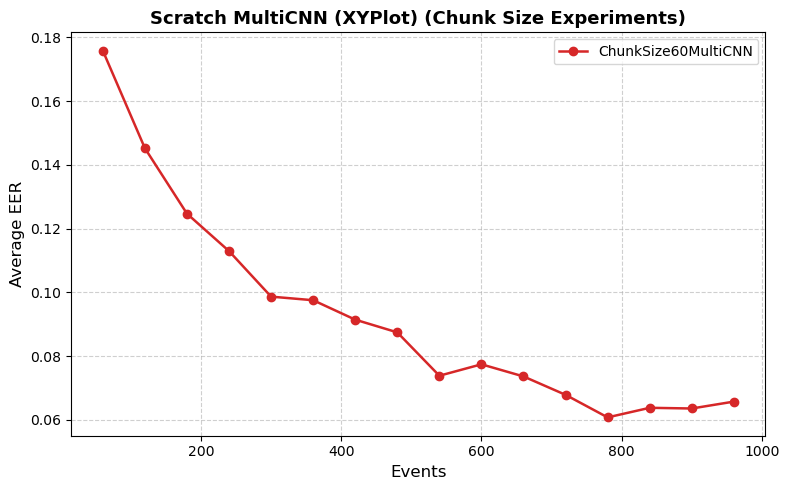

In [41]:
plot_chunk_json_curves("Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot", max_event=1000, model="Scratch MultiCNN (XYPlot)")

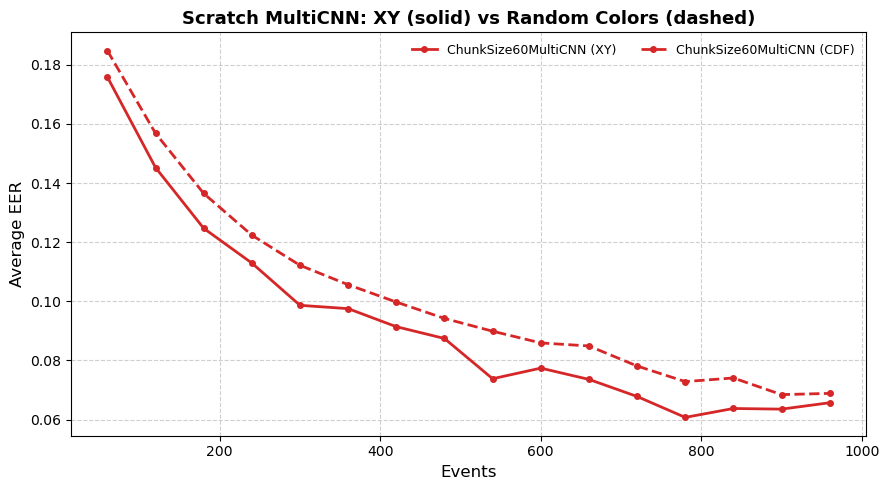

In [42]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/XYPlot/RandomColors",
    title="Scratch MultiCNN: XY (solid) vs Random Colors (dashed)",
    max_event=1000
)

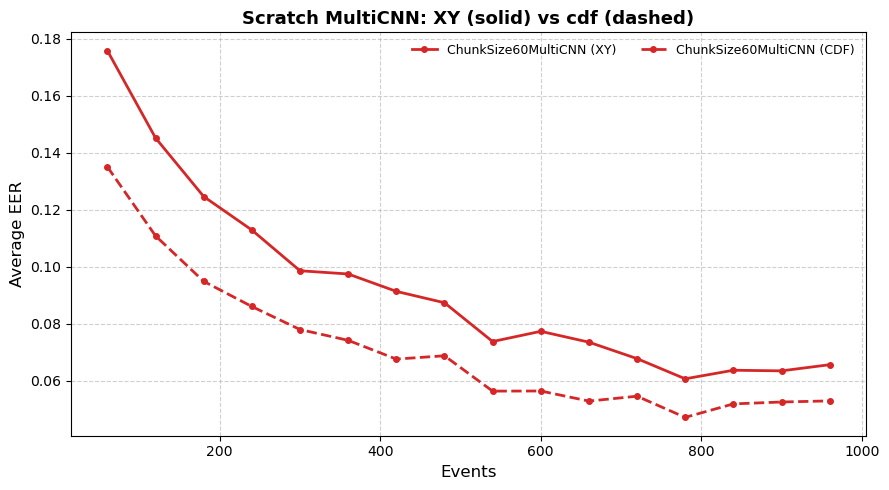

In [43]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/XYPlot/cdf",
    title="Scratch MultiCNN: XY (solid) vs cdf (dashed)",
    max_event=1000
)

In [9]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Protocol1/Scratch_MultiCNN/XYPlot/per-userXYPlot/ChunkSize60MultiCNN.json"
json_cdf = "Results/Protocol1/Scratch_MultiCNN/XYPlot/per-usercdf/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,17.59,13.51,4.07,0.001953,True
1,XYPlot vs CDF,2,10,14.52,11.09,3.43,0.001953,True
2,XYPlot vs CDF,3,10,12.47,9.49,2.98,0.003906,True
3,XYPlot vs CDF,4,10,11.29,8.61,2.68,0.005859,True
4,XYPlot vs CDF,5,10,9.87,7.80,2.06,0.009766,True
5,XYPlot vs CDF,6,10,9.75,7.43,2.33,0.005859,True
6,XYPlot vs CDF,7,10,9.14,6.77,2.38,0.005859,True
7,XYPlot vs CDF,8,10,8.74,6.88,1.86,0.130859,False
8,XYPlot vs CDF,9,10,7.38,5.64,1.74,0.083984,False
9,XYPlot vs CDF,10,10,7.74,5.65,2.09,0.019531,True


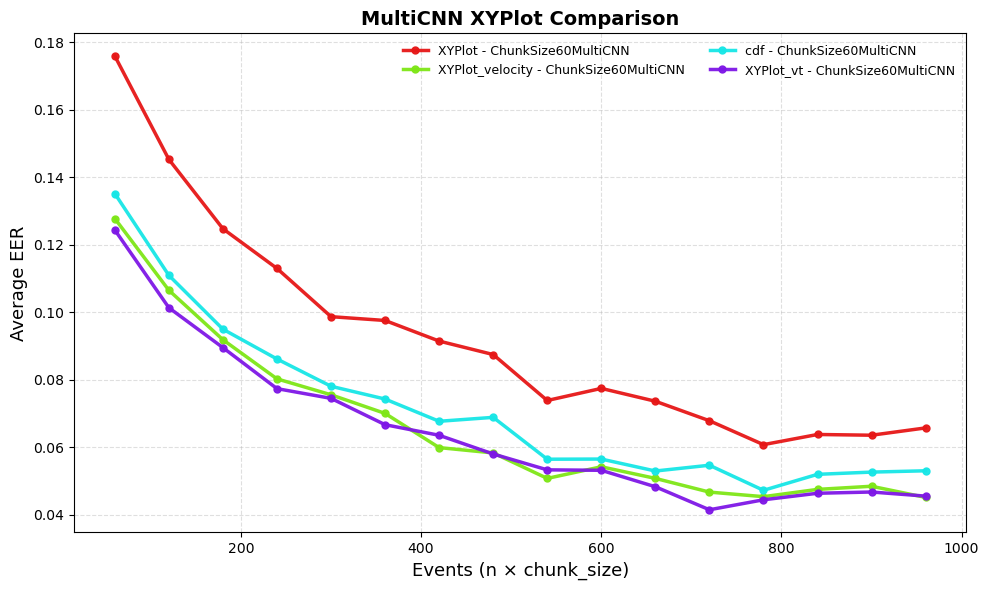

In [46]:
dir_list = ["Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot","Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot_velocity",
"Results/Protocol1/Scratch_MultiCNN/XYPlot/cdf","Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot_vt"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN XYPlot Comparison",
    chunk_sizes=60
)

## SRP

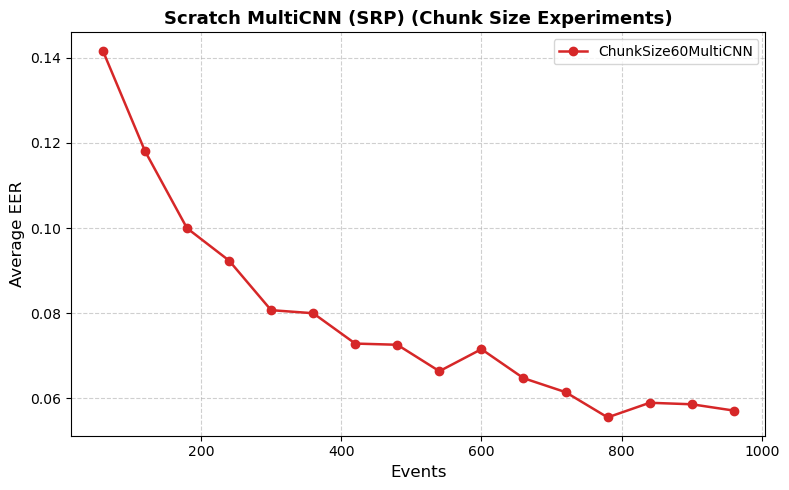

In [10]:
plot_chunk_json_curves("Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel", max_event=1000, model="Scratch MultiCNN (SRP)")

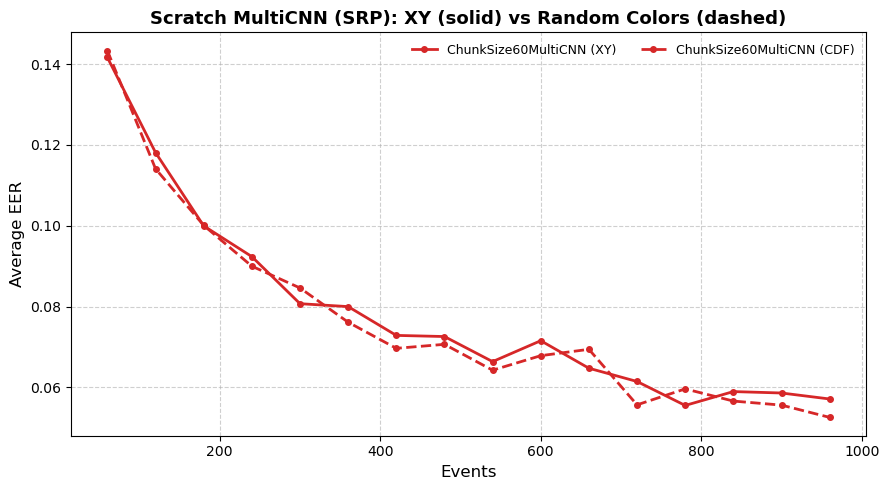

In [11]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/SRP/RandomColors",
    title="Scratch MultiCNN (SRP): XY (solid) vs Random Colors (dashed)",
    max_event=1000
)

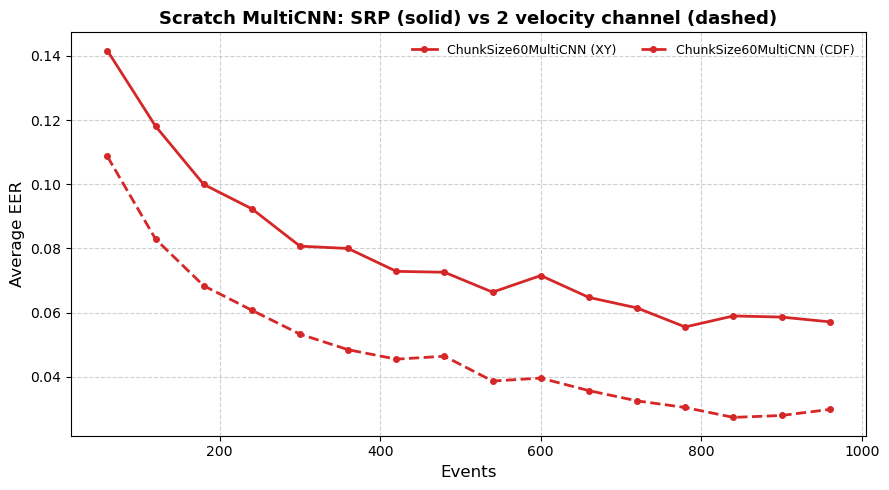

In [12]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/SRP/VelocityChannel",
    title="Scratch MultiCNN: SRP (solid) vs 2 velocity channel (dashed)",
    max_event=1000
)

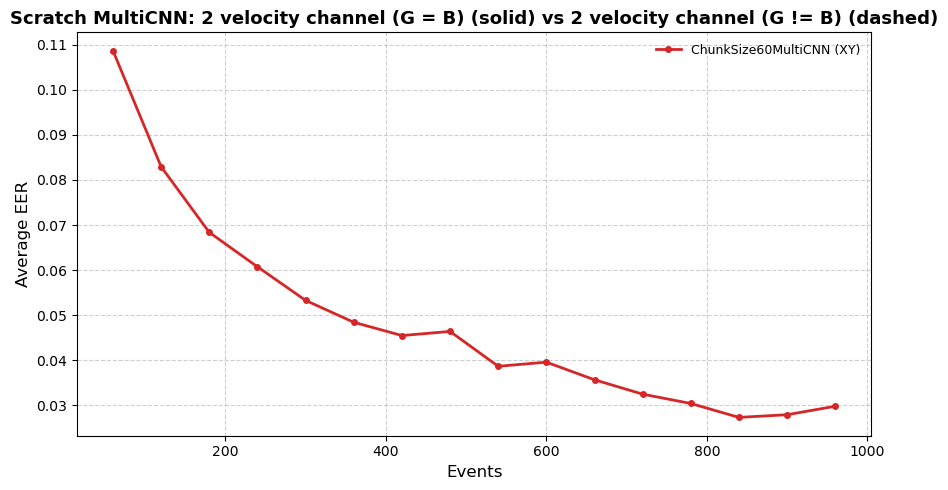

In [13]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/VelocityChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/SRP/VelocitySymChannel",
    title="Scratch MultiCNN: 2 velocity channel (G = B) (solid) vs 2 velocity channel (G != B) (dashed)",
    max_event=1000
)

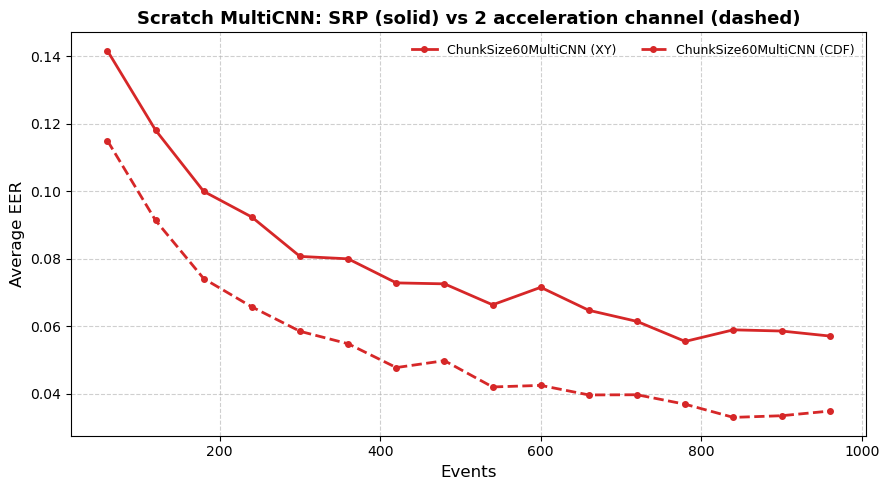

In [14]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/SRP/AccelerationChannel",
    title="Scratch MultiCNN: SRP (solid) vs 2 acceleration channel (dashed)",
    max_event=1000
)

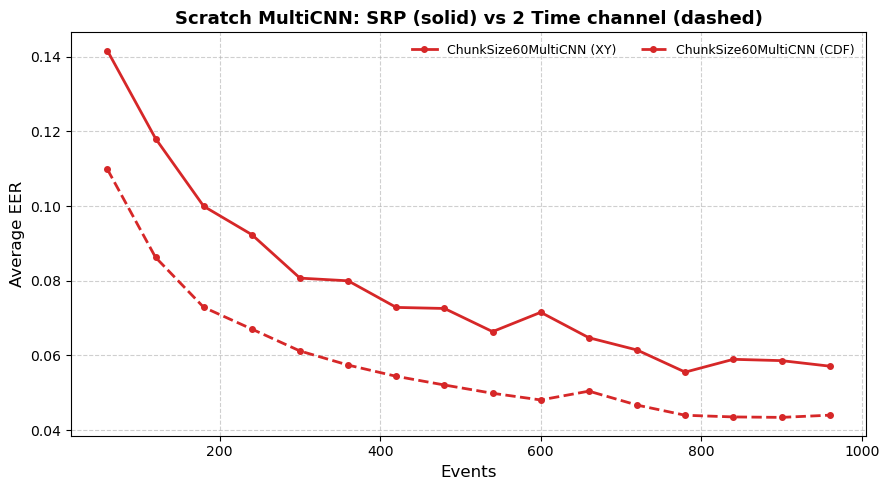

In [15]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiCNN/SRP/TimeChannel",
    title="Scratch MultiCNN: SRP (solid) vs 2 Time channel (dashed)",
    max_event=1000
)

In [16]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Protocol1/Scratch_MultiCNN/SRP/per-userOneChannel/ChunkSize60MultiCNN.json"
json_cdf = "Results/Protocol1/Scratch_MultiCNN/SRP/per-userVelocityChannel/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot",
    label_b="CDF",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot),Mean EER (CDF),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot vs CDF,1,10,14.16,10.87,3.30,0.003906,True
1,XYPlot vs CDF,2,10,11.81,8.29,3.52,0.003906,True
2,XYPlot vs CDF,3,10,10.00,6.84,3.16,0.005859,True
3,XYPlot vs CDF,4,10,9.24,6.07,3.16,0.005859,True
4,XYPlot vs CDF,5,10,8.07,5.33,2.74,0.019531,True
5,XYPlot vs CDF,6,10,8.00,4.84,3.15,0.013672,True
6,XYPlot vs CDF,7,10,7.29,4.55,2.74,0.109745,False
7,XYPlot vs CDF,8,10,7.26,4.64,2.62,0.050612,False
8,XYPlot vs CDF,9,10,6.64,3.87,2.77,0.050612,False
9,XYPlot vs CDF,10,10,7.16,3.96,3.20,0.028402,True


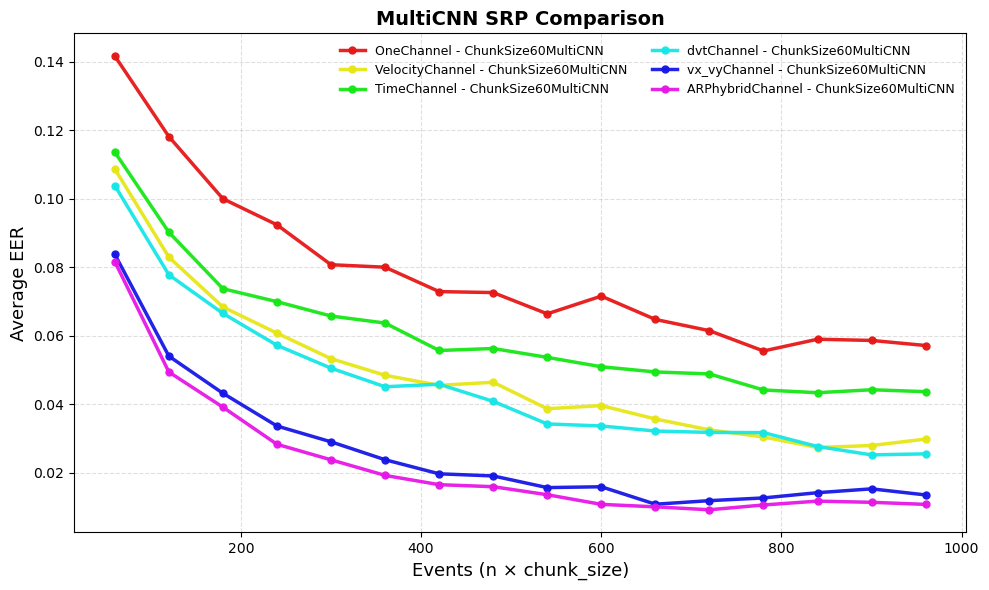

In [34]:
dir_list = ["Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel","Results/Protocol1/Scratch_MultiCNN/SRP/VelocityChannel",
            "Results/Protocol1/Scratch_MultiCNN/SRP/TimeChannel","Results/Protocol1/Scratch_MultiCNN/SRP/dvtChannel",
            "Results/Protocol1/Scratch_MultiCNN/SRP/vx_vyChannel","Results/Protocol1/Scratch_MultiCNN/SRP/ARPhybridChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison",
    chunk_sizes=60
)

In [31]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Protocol1/Scratch_MultiCNN/SRP/per-userdvtChannel/ChunkSize60MultiCNN.json"
json_cdf = "Results/Protocol1/Scratch_MultiCNN/SRP/per-uservx_vyChannel/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="dvt",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (dvt),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,dvt vs vx_vy,1,10,9.40,8.37,1.02,0.105469,False
1,dvt vs vx_vy,2,10,6.94,5.40,1.54,0.015156,True
2,dvt vs vx_vy,3,10,5.46,4.32,1.14,0.050612,False
3,dvt vs vx_vy,4,10,4.51,3.36,1.15,0.007686,True
4,dvt vs vx_vy,5,10,3.66,2.90,0.76,0.313938,False
5,dvt vs vx_vy,6,10,3.53,2.38,1.15,0.038152,True
6,dvt vs vx_vy,7,10,3.21,1.97,1.24,0.010862,True
7,dvt vs vx_vy,8,10,2.91,1.91,1.01,0.066316,False
8,dvt vs vx_vy,9,10,2.46,1.57,0.90,0.038152,True
9,dvt vs vx_vy,10,10,2.27,1.59,0.68,0.213524,False


## ViT


## XYPlot


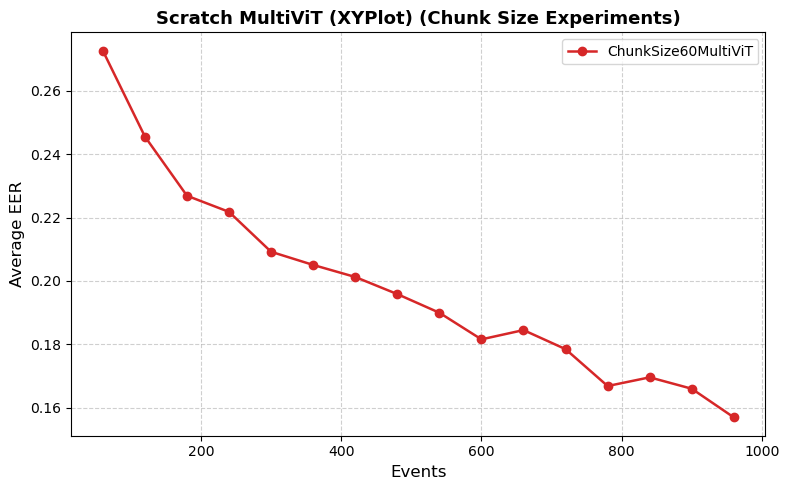

In [19]:
plot_chunk_json_curves("Results/Protocol1/Scratch_MultiViT/XYPlot/XYPlot", max_event=1000, model="Scratch MultiViT (XYPlot)")

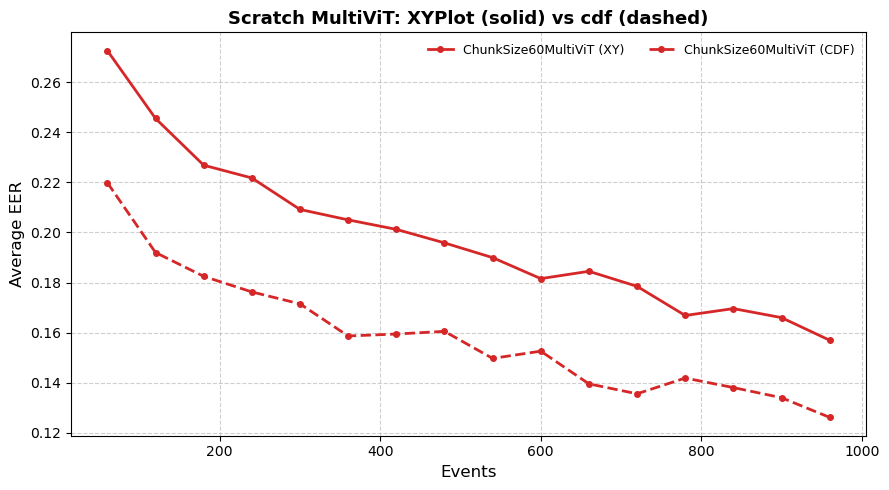

In [20]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiViT/XYPlot/XYPlot",
    cdf_dir="Results/Protocol1/Scratch_MultiViT/XYPlot/cdf",
    title="Scratch MultiViT: XYPlot (solid) vs cdf (dashed)",
    max_event=1000
)

## SRP

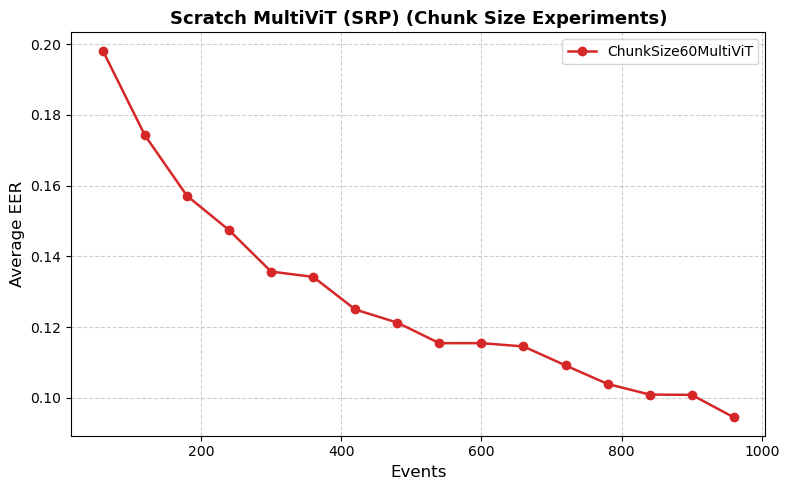

In [21]:
plot_chunk_json_curves("Results/Protocol1/Scratch_MultiViT/SRP/OneChannel", max_event=1000, model="Scratch MultiViT (SRP)")

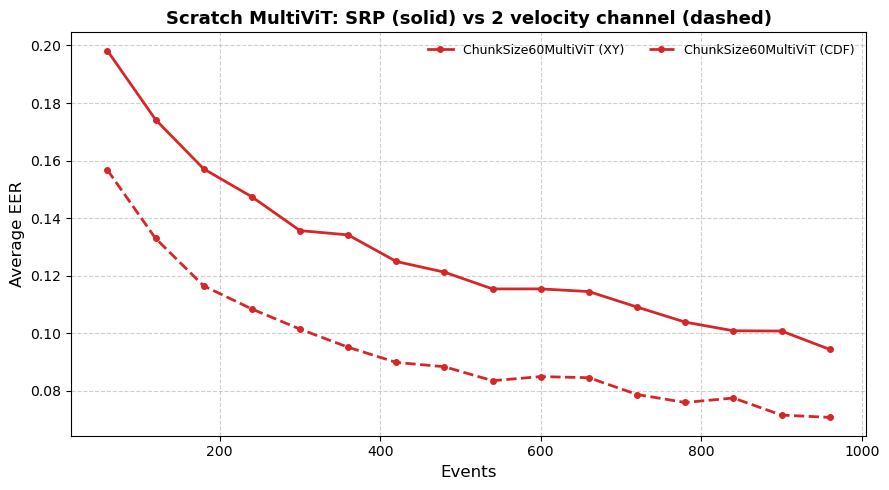

In [22]:
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiViT/SRP/OneChannel",
    cdf_dir="Results/Protocol1/Scratch_MultiViT/SRP/VelocityChannel",
    title="Scratch MultiViT: SRP (solid) vs 2 velocity channel (dashed)",
    max_event=1000
)

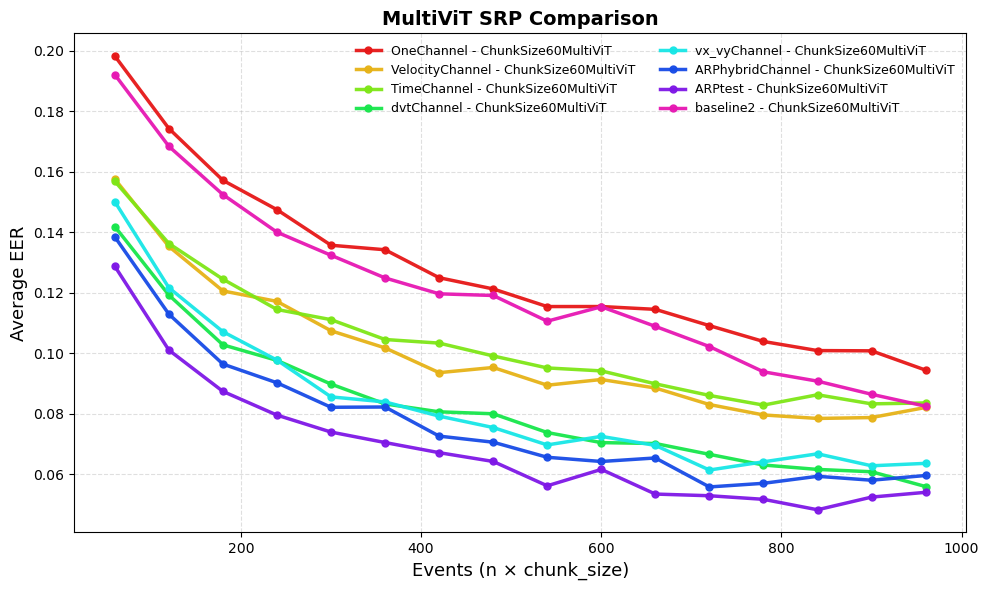

In [40]:
dir_list = ["Results/Protocol1/Scratch_MultiViT/SRP/OneChannel","Results/Protocol1/Scratch_MultiViT/SRP/VelocityChannel",
            "Results/Protocol1/Scratch_MultiViT/SRP/TimeChannel","Results/Protocol1/Scratch_MultiViT/SRP/dvtChannel",
            "Results/Protocol1/Scratch_MultiViT/SRP/vx_vyChannel","Results/Protocol1/Scratch_MultiViT/SRP/ARPhybridChannel",
            "Results/Protocol1/Scratch_MultiViT/SRP/ARPtest","Results/Protocol1/Scratch_MultiViT/SRP/baseline2"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiViT SRP Comparison",
    chunk_sizes=60
)

## Protocol2


## CNN

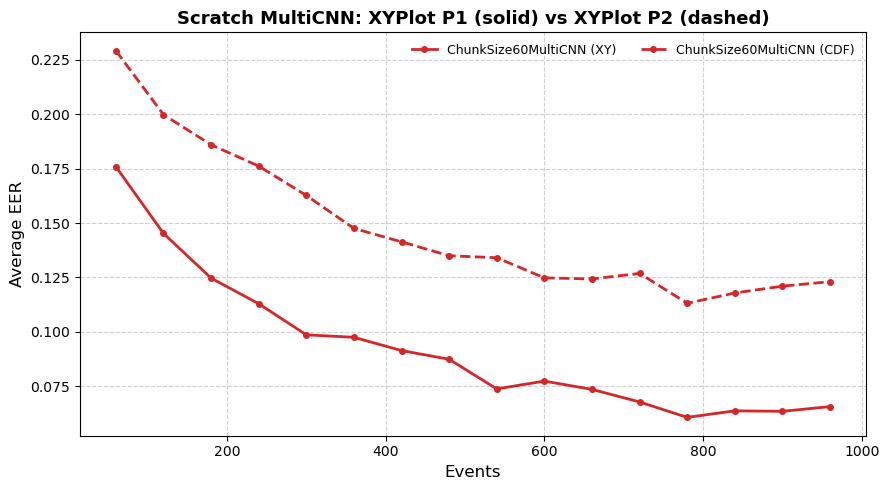

In [24]:
# Baseline
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot",
    cdf_dir="Results/Protocol2/Scratch_MultiCNN/XYPlot/XYPlot",
    title="Scratch MultiCNN: XYPlot P1 (solid) vs XYPlot P2 (dashed)",
    max_event=1000
)

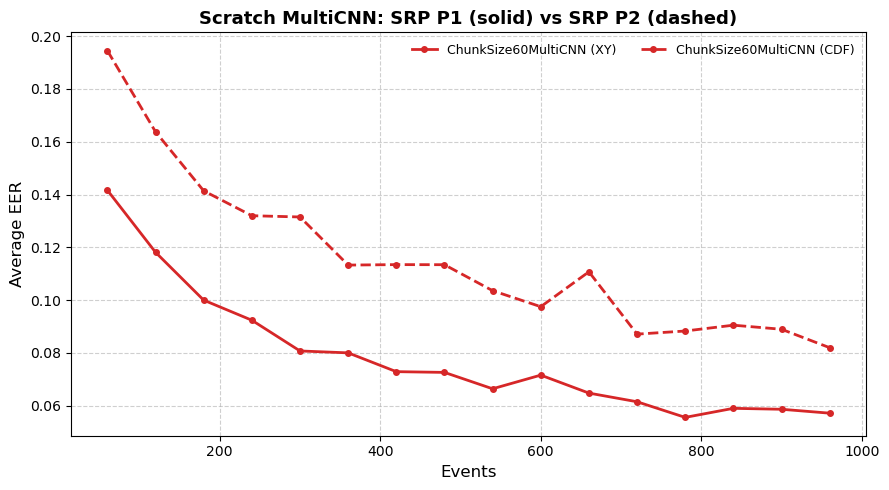

In [25]:
# Baseline Comparison
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol1/Scratch_MultiCNN/SRP/OneChannel",
    cdf_dir="Results/Protocol2/Scratch_MultiCNN/SRP/OneChannel",
    title="Scratch MultiCNN: SRP P1 (solid) vs SRP P2 (dashed)",
    max_event=1000
)

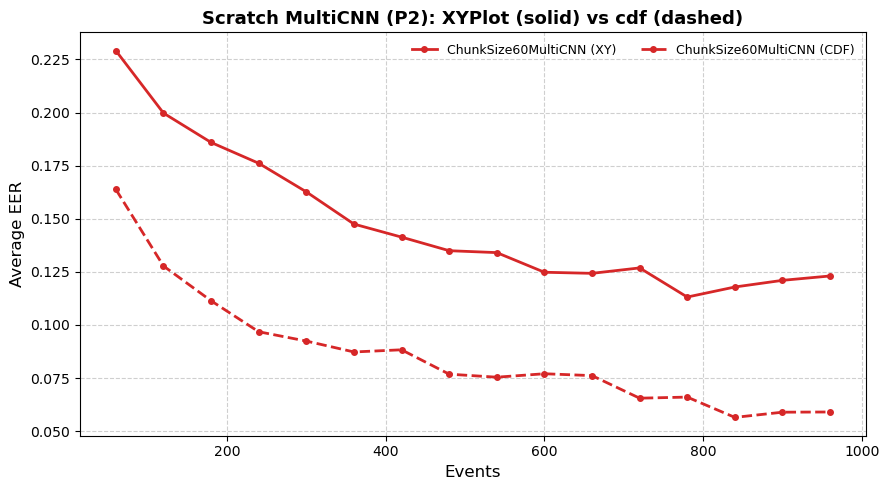

In [26]:
# Baseline
plot_chunk_xy_cdf_curves(
    xy_dir="Results/Protocol2/Scratch_MultiCNN/XYPlot/XYPlot",
    cdf_dir="Results/Protocol2/Scratch_MultiCNN/XYPlot/cdf",
    title="Scratch MultiCNN (P2): XYPlot (solid) vs cdf (dashed)",
    max_event=1000
)

## ViT
